## Module 4: Cancer

## Team Members:
Kai-Tang Tseng, Mohamed Elfaki

## Project Title:
Prediction of Mortality Rate in Glioblastoma Multiforme with expression of Angiogenesis Hallmark using Machine Learning Framework


## Project Goal:
The goal of this project is to investigate the question of whether or not expression of angiogenesis hallmark can predict Disease-Specific Survival (DSS) (Mortality Rate) of Glioblastoma Patients. This project utilizes machine learning frameworks such as the unsupervised learning method of Principal Component Analysis (PCA) for dimension reduction and K-Means Clustering for subtype grouping to visualize the data. After visualization, the supervised learning technique of Decision Tree is utilized on the PCA data to perform classification in predicting DSS outcome for patients base solely on the PCA Angiogenesis gene expression.

## Disease Background: 

### Gilblastoma Multiforme (also known as just Giloblastoma)'s Background Information

* Prevalence & incidence : Glioblastoma is the most common primary malignant brain tumor in adults, with an incidence of approximately 3–4 cases per 100,000 people per year. It has a very poor prognosis, with median survival around 12–15 months.

* Risk factors (genetic, lifestyle) & Societal determinants : Risk factors include genetic mutations, prior exposure to radiation, and age (more common in older adults). Lifestyle factors are not strongly linked, but access to healthcare can influence diagnosis and outcomes.

* Standard of care treatments (& reimbursement) : Standard treatment includes surgical removal of the tumor followed by radiation therapy and chemotherapy (typically temozolomide). Despite treatment, recurrence is common due to the tumor’s aggressive nature.

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) : Glioblastoma grows rapidly and invades surrounding brain tissue. It promotes angiogenesis through factors like VEGFA, which stimulate blood vessel formation to supply nutrients and oxygen, supporting tumor survival and expansion. (There are 
two types of Glioblastoma, Primary Glioblastoma which just appears prior to a former Glioma and Secondary Glioblastoma which progresses from a Low-Grade Glioma (LGG)) (Ohgaki & Kleihues, 2013)

### Cancer Hallmark : 

* Cancer hallmark focus: Angiogenesis

* Overview of hallmark: Angiogenesis is the process by which new blood vessels form from existing ones. In cancer, this allows tumors to receive oxygen and nutrients, enabling rapid growth and survival. Glioblastoma (GBM) is a highly aggressive brain tumor that relies heavily on angiogenesis to sustain its rapid progression.

* Genes associated with hallmark to be studied : CXCR4	CXCL13	FLT4	RHOA	TGFB2	GAB1	STAT3	LCK	FZD4	PDPK1	CDH5	HIF1A	MTOR	CXCL12	ITGA5	PLCG1	RRAS	ENG	TNFSF12	PTPN11	TGFBR1	TERT	PIK3CD	PTK2B	LEP	FGF2	NOS3	VTN	CCL24	SMO	KDR	PRKCG	RAF1	VEGFA	BRCA1	CCL2	TGFBR2	EGFR	VAV2	VEGFB	KRAS	IL6	ERBB2	PRKCA	ROCK1	TNF	IL1B	SDC4	PRKACA	CX3CR1	ITGB1	PDGFA	CD40	MAPK1	CXCL8	PIK3R1	FIGF	CSF3	HGF	VEGFD	IL10	MET	TP53	SDC2	TGFB1	AKT1	FLT1	CAV1	ARNT	ARHGEF1	PDGFRA	HSPB1	TWIST1	ITGB3	AKT3	MMP1	MAPK3	SPHK1	EPAS1	TIMP3	CXCR2	SRC	CXCL10	MAP2K1	WNT5A	EFNA1	IGF1	IL8	ROCK2	ACKR3	GATA2	VEGFC	CCR3	CTNNB1	TEK	FN1	EPHA2	IGF1R	THBS1	FES	ITGAV	CXCL9	CCL11	MYC	CXCR3	PRKCB	ACVRL1	HRAS	ESR1	TGFB3	PLAUR	RAC1	NF1	ANGPT2	GRB2	PIK3CA	IL1A 


Additional Genes linked to Angiogenesis of Glioblastoma : CXCR1, CXCR2, PDGFB (Biterge-Sut,2020 & D'Alessio et al, 2016)


## Data-Set: 

In this study, we will analysis the subset of Glioblastoma Multiforme (GBM).

The data is collected from The Cancer Genome Atlas Program (TCGA) which collects the metadata and the RNA Gene Expression Data. For each cancer patients, a specific ID is assigned, and metadata such as background information including cancer stages, age, sex, and other informations are collected. Gene Expression Data is collected through RNA extraction from the patient's sample where the RNA is then sequenced and quantified using Next Generation Sequencing. Gene expression is measured in Transcripts Per Million (TPM), a unit that normalized for gene length. It is then further transformed using the following formula : $\log_{2}(\text{TPM} + 1)$ to reduce data skewness. (1 is added to handle zero-expression values).

From the dataset, we subsetted the data relating to GBM and also filter out for our gene of interest (Angiogenesis hallmarks).

The data can be access here : https://portal.gdc.cancer.gov/ 


## Data Analysis: 


### 0. Importing Dependeicies

For this python analysis project, a lot of pre-writtern and pre-published python libraies are available to be use. Here we import them including pandas (to extract data from the dataset), matplotlib and seaborn (to plot datas), and various sklearn libraries (implementing various unsupervised machine learning algorithms.)

In [90]:
# Data Extraction
import pandas as pd 
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Math Calculations
import numpy as np
# Machine Learning Algorthim
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 1. Filtering Datasets

The dataset of gene expression and metadeta contains a large amount of data that does not relate to the scope of this project (i.e different cancer type, different gene of interest). Therfore, to effectively utilize the dataset, it needs to be filtered and subset to have exactly the desired datasets.

#### 1.1 Extracting Data

Use pandas to extra all data from Training Set of Gene Expression and Metadata.

In [91]:
data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  
metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(data.head())

        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

#### 1.2 Filtering out GBM

Use the metadata to determine which patients are diagnosis with Glioblastoma Multiforme (GBM) and then filter out those patients from the gene dosage data file to obtain a new data with the gene expression of many genes only from GBM Patients.

In [92]:
cancer_type = 'GBM'  # Glioblastoma Multiforme

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
GBM_data = data[cancer_samples]

Index(['TCGA-06-0184-01A-01R-1849-01', 'TCGA-27-2524-01A-01R-1850-01',
       'TCGA-27-1835-01A-01R-1850-01', 'TCGA-26-5139-01A-01R-1850-01',
       'TCGA-06-2567-01A-01R-1849-01', 'TCGA-28-5216-01A-01R-1850-01',
       'TCGA-06-0168-01A-01R-1849-01', 'TCGA-32-1980-01A-01R-1850-01',
       'TCGA-76-4932-01A-01R-1850-01', 'TCGA-06-2557-01A-01R-1849-01',
       'TCGA-06-0141-01A-01R-1849-01', 'TCGA-06-0211-01B-01R-1849-01',
       'TCGA-06-0210-01A-01R-1849-01', 'TCGA-26-5136-01B-01R-1850-01',
       'TCGA-14-1823-01A-01R-1849-01', 'TCGA-15-0742-01A-01R-1850-01',
       'TCGA-41-2572-01A-01R-1850-01', 'TCGA-26-5133-01A-01R-1850-01',
       'TCGA-06-2570-01A-01R-1849-01', 'TCGA-19-1390-01A-01R-1850-01',
       'TCGA-28-5208-01A-01R-1850-01', 'TCGA-12-3650-01A-01R-1849-01',
       'TCGA-16-0846-01A-01R-1850-01', 'TCGA-12-5299-01A-02R-1849-01',
       'TCGA-32-1982-01A-01R-1850-01', 'TCGA-06-0174-01A-01R-1849-01',
       'TCGA-19-2619-01A-01R-1850-01', 'TCGA-06-0125-01A-01R-1849-01',
      

#### 1.3 Filtering Out the Gene of Interest

From the new filtered data of only the GBM Patients, next we filter out only the columns with gene of interest. Our project involves looking at the risk factors of angiogenesis genes thus we filter the dataset to only include our gene of interest relating to angiogenesis both known angiogenesis genes for GBM as well as cancer as a whole.

In [93]:
desired_gene_list = [
    'VEGFA', 'VEGFB', 'KDR', 'CXCR1', 'CXCR2', 'HIF1A', 'PDGFB', 'MYC', 'CDH5', 'KRAS', 'IL8',
    'CXCR4', 'CXCL13', 'FLT4', 'RHOA', 'TGFB2', 'GAB1', 'STAT3', 'LCK', 'FZD4', 'PDPK1', 'MTOR',
    'CXCL12', 'ITGA5', 'PLCG1', 'RRAS', 'ENG', 'TNFSF12', 'PTPN11', 'TGFBR1', 'TERT', 'PIK3CD',
    'PTK2B', 'FGF2', 'NOS3', 'VTN', 'CCL24', 'SMO', 'PRKCG', 'RAF1', 'BRCA1', 'CCL2',
    'TGFBR2', 'EGFR', 'VAV2', 'IL6', 'ERBB2', 'PRKCA', 'ROCK1', 'TNF', 'IL1B', 'SDC4', 'PRKACA',
    'CX3CR1', 'ITGB1', 'PDGFA', 'CD40', 'MAPK1', 'PIK3R1', 'CSF3', 'HGF', 
    'IL10', 'MET', 'TP53', 'SDC2', 'TGFB1', 'AKT1', 'FLT1', 'CAV1', 'ARNT', 'ARHGEF1', 'PDGFRA',
    'HSPB1', 'TWIST1', 'ITGB3', 'AKT3', 'MMP1', 'MAPK3', 'SPHK1', 'EPAS1', 'TIMP3', 'SRC',
    'CXCL10', 'MAP2K1', 'WNT5A', 'EFNA1', 'IGF1', 'ROCK2', 'GATA2', 'VEGFC', 
    'CTNNB1', 'TEK', 'FN1', 'EPHA2', 'IGF1R', 'THBS1', 'FES', 'ITGAV', 'CXCL9', 'CCL11',
    'CXCR3', 'PRKCB', 'ACVRL1', 'HRAS', 'ESR1', 'TGFB3', 'PLAUR', 'RAC1', 'NF1', 'ANGPT2',
    'GRB2', 'PIK3CA', 'IL1A'
]

gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
GBM_gene_data = GBM_data.loc[gene_list]
print(GBM_gene_data)

        TCGA-06-0184-01A-01R-1849-01  TCGA-27-2524-01A-01R-1850-01  \
VEGFA                       6.298026                      8.350761   
VEGFB                       7.657397                      7.286662   
KDR                         3.332119                      2.700655   
CXCR1                       1.511057                      0.000000   
CXCR2                       2.449790                      0.559835   
...                              ...                           ...   
NF1                         2.353745                      1.471186   
ANGPT2                      4.945793                      4.544121   
GRB2                        6.938205                      7.047229   
PIK3CA                      3.819506                      2.576088   
IL1A                        1.245300                      2.497110   

        TCGA-27-1835-01A-01R-1850-01  TCGA-26-5139-01A-01R-1850-01  \
VEGFA                       7.761174                      9.492876   
VEGFB              

### 2. Princial Component Analysis (PCA)

Principal Component Analysis (PCA) is a machine learning method that performs dimension reductions allowing the visualization of a dataset with a lot of dimensions. 

In this case, there is two large variability of variables gene type and a variety of different patients. Looking at just two genes, we can plot them against each other in a 2D graph with Gene 1 in X-Axis and Gene 2 in Y-Axis to visualize each patient having higher Gene 1 Concentration, Gene 2 Concentration, Both, or None. With three genes, the same ideas applied but just in a 3-D Graph. However, as we expand the amount of genes, it becomes too high of a dimension to graph. Thus we use PCA to perform "Dimension Reduction" to reduce the dataset from a higher number of different variables (Genes) to a 2-D Graph with Principal Component (PC) 1 and PC2. PC1 is calculated as the line with the highest variations and PC2 being orthogonal to PC1. This effectively reduce the dimensions of a multi-dimensional dataset to just 2 dimensions for analysis.

Here, we use PCA to look at the relationship to find groupings of different patients ploted by genes with target of DSS to visualize in angiogenesis gene somehow contributes to DSS rate. The dots are represented as individual patients and the dimensions are the genes (which is then transformed into PC1 and PC2)

(Supplemental Information : https://www.youtube.com/watch?v=HMOI_lkzW08)

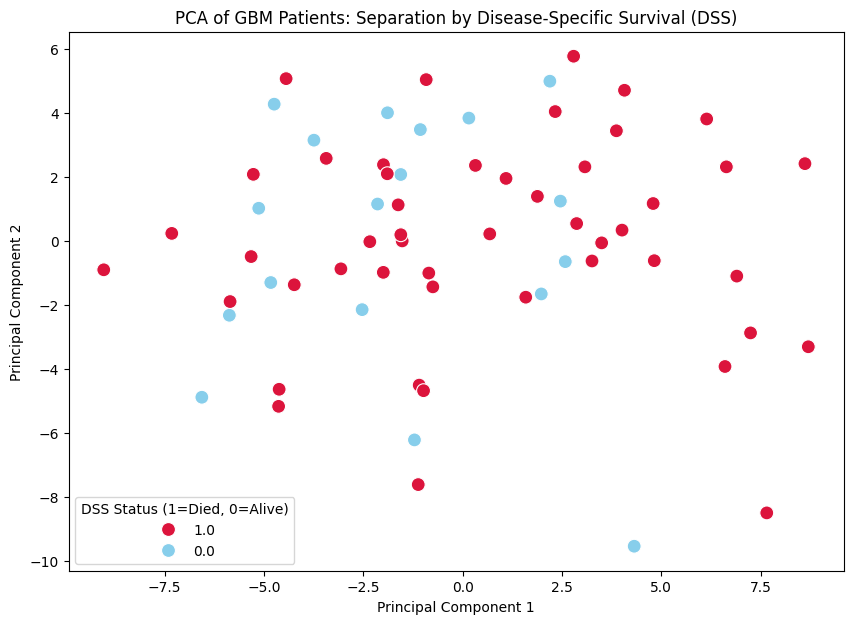

In [94]:
# 1. Flip the data: Rows must be Patients, Columns must be Genes
# This allows each dot on the plot to represent a person
X = GBM_gene_data.T 

# 1. Flip the data
X_all = GBM_gene_data.T 

# 2. Align labels and find where DSS is NOT null
y_all = metadata_df.loc[X_all.index, 'DSS']
mask = y_all.notna()  # This finds only the True values (0.0 or 1.0)

# 3. Filter BOTH at the same time
X_filtered = X_all[mask]
y_filtered = y_all[mask]

# 4. Now run PCA on ONLY the filtered data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_filtered)

# 4. Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_filtered.astype(str), 
    palette={'0.0': 'skyblue', '1.0': 'crimson', 'nan': 'grey'},
    s=100
)

plt.title("PCA of GBM Patients: Separation by Disease-Specific Survival (DSS)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DSS Status (1=Died, 0=Alive)")
plt.show()

### 3. K-Means Cluster

K-Means Cluster in an unsupervised machine learning algorithm that group data points into distinct "clusters" based on their similarities. It performs this by minimizing the distance between the patients in a cluster and the cluster's center (centroid). It pick 3 random spots to be the "avearge", each patient is assigned to the cluster they are most similar to, and the center move until the groups are as distinct as possible.

Here, we use K-Means Clustering to group patients who's gene expression behave similarity.

The goal is to identify potential clusters of patients that passed away which then can identify the gene family / type that is most associated with DSS. Each cluster is determined using K-Means Cluster and then their mortality rate (DSS) is then calculated from the average mortality rate of each patients in that cluster.

#### 3.1 Perform the K-Means Clustering

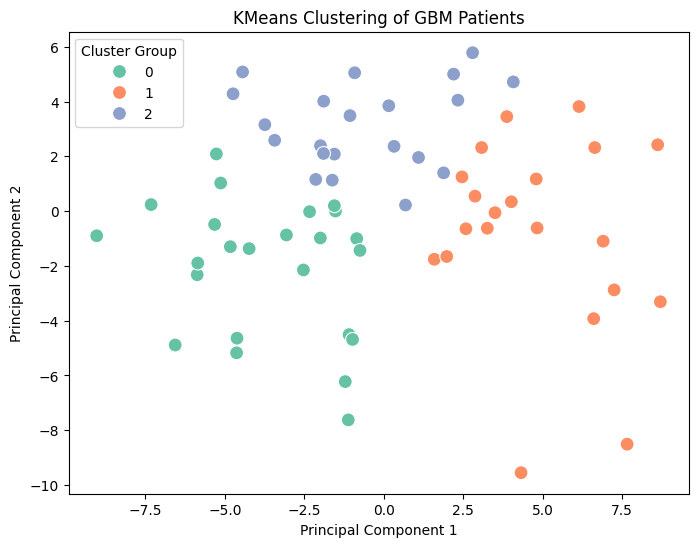

In [95]:
from sklearn.cluster import KMeans

# 1. Fit KMeans 
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_pca) # Clustering based on PCA components

plt.figure(figsize=(8, 6))

# 2. Plotting PCA
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=clusters, 
    palette="Set2", 
    s=100
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering of GBM Patients")
plt.legend(title="Cluster Group")
plt.show()

#### 3.2 Find the Mortality Rate Associated with Each Cluster

In [96]:
# Obtain 
analysis_df = pd.DataFrame({'Cluster': clusters, 'DSS': y_filtered.values})
analysis_df['DSS'] = pd.to_numeric(analysis_df['DSS'], errors='coerce')

# Calculate the mortality rate per cluster
mortality_rates = analysis_df.groupby('Cluster')['DSS'].mean() * 100

print("--- Mortality Rate per Cluster ---")
for cluster_id, rate in mortality_rates.items():
    print(f"Cluster {cluster_id}: {rate:.2f}% mortality")

--- Mortality Rate per Cluster ---
Cluster 0: 75.00% mortality
Cluster 1: 80.95% mortality
Cluster 2: 61.90% mortality


Based on the K-Mean Clustering on PCA Transformed Dataset, it seems there is differing mortality rate associated with different gene clusters. This may be a good indication that angiogenesis hallmark somewhat plays a role in DSS.

### 4. Supervised Learning : Classification with Decision Tree

Based on gene data we want to be able to predict mortality rate just simply based on angiogenesis gene expression by outputting 1 (deceased) and 0 (alive) by Disease Specific Survival. Due to the limitation of the datasets, we split the training dataset into 70% into training data, 20% into validation data, and 10% into final testing data.

In [97]:
# AI Usage Statement : Use Gemini 3 to assist in generating the Decision Tree Code and the subsequent validations.

# Using PCA data and labels of metadata after dropping NaNs asthe target
X_tree = X_pca 
y_tree = y_filtered.astype(int) 

# Stage 1: Split off the 70% Training set
# The remaining 30% goes into a temporary variable (X_temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tree, y_tree, test_size=0.30, random_state=42
)

# Stage 2: Split the 30% temporary set into Validation and Test
# Since 10% is 1/3 of the 30% temporary set, we use test_size=0.33
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42
)


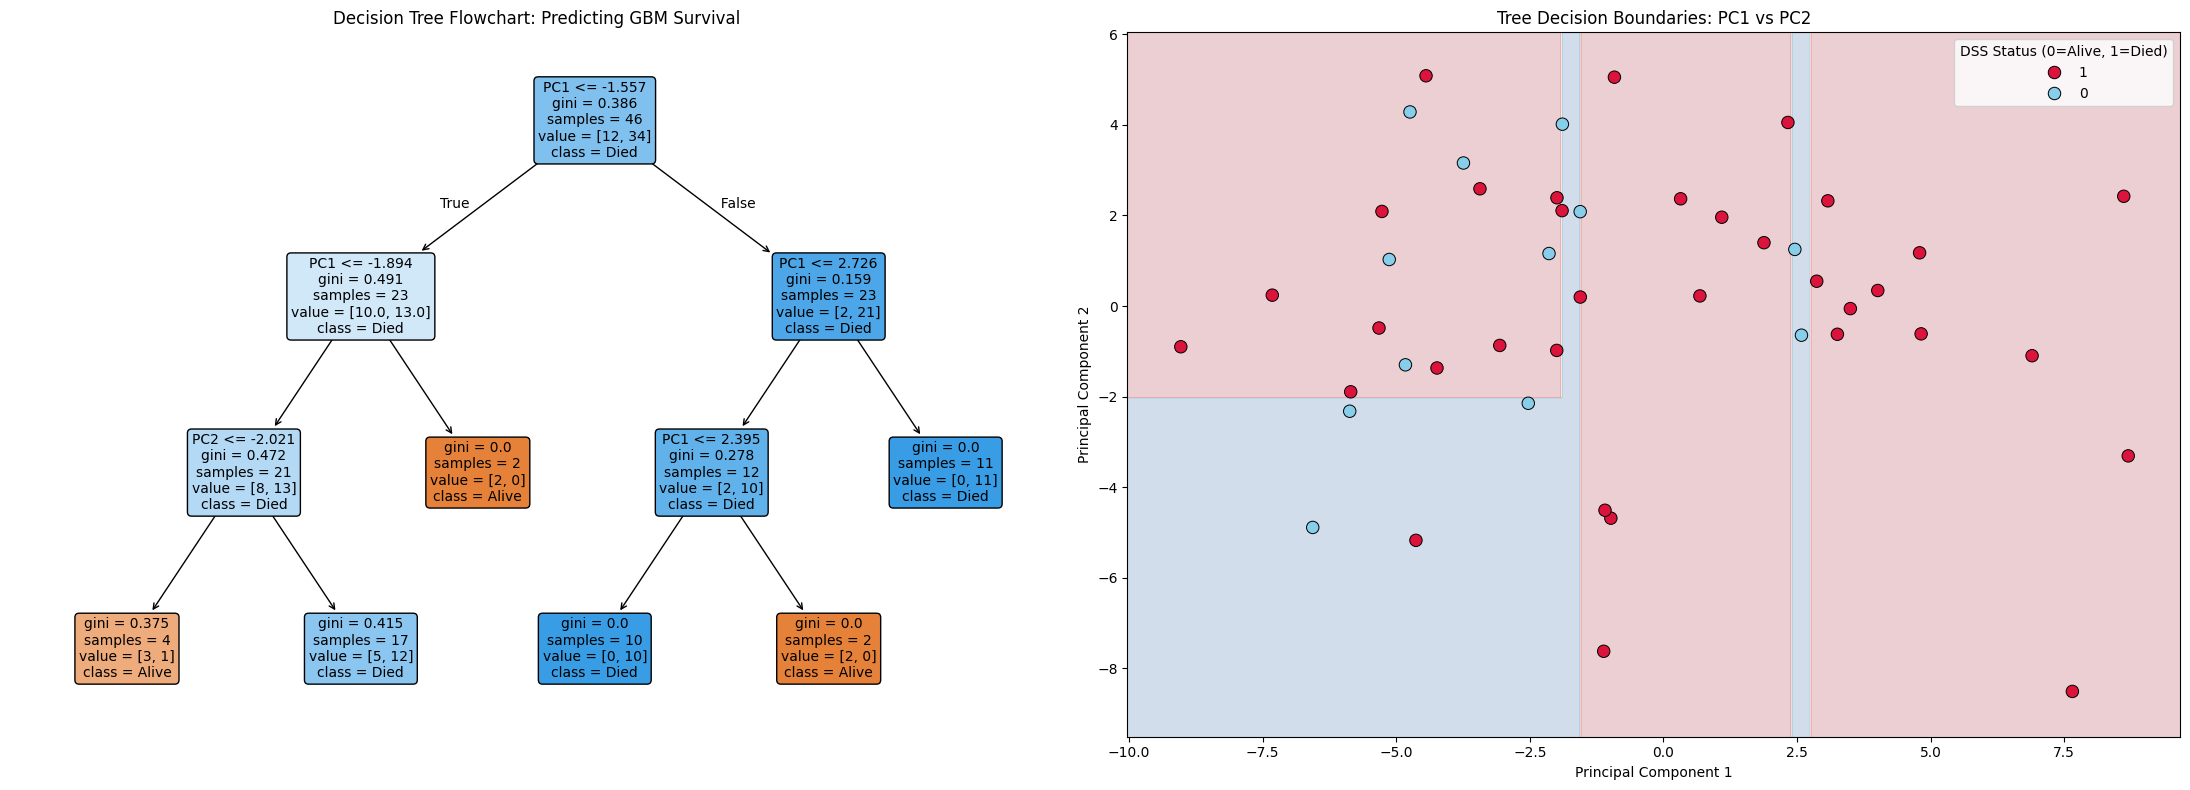

In [98]:
# Build the Decision Tree Model with max_depth of 3, meaning it can make 3 decisions splits
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. LEFT SIDE: Tree Structure ---
plot_tree(tree_model, 
          feature_names=['PC1', 'PC2'], 
          class_names=['Alive', 'Died'], 
          filled=True, 
          rounded=True,
          fontsize=10,
          ax=ax[0]) # Pass the first axis
ax[0].set_title("Decision Tree Flowchart: Predicting GBM Survival")

# --- 2. RIGHT SIDE: Decision Boundaries ---
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get background predictions
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours on the second axis
ax[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r') 

# Add the scatterplot to the second axis
sns.scatterplot(
    x=X_train[:, 0], 
    y=X_train[:, 1], 
    hue=y_train.astype(str), 
    palette={'0': 'skyblue', '1': 'crimson'},
    edgecolor='black',
    s=80,
    ax=ax[1] # Pass the second axis
)

ax[1].set_title("Tree Decision Boundaries: PC1 vs PC2")
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].legend(title="DSS Status (0=Alive, 1=Died)")

plt.tight_layout()
plt.show()

#### 4.1 In-Sample Error and Out-Of-Sample Error

With the dataset beings partictions into Training Dataset (70%) and Validation Dataset (20%), the In-Sample Error of the Training Dataset and Out-Of-Sample Error of Validation Dataset can be examined. The error can be visualized first by a direction calculation of error precentage and then proceed to visualize through a Confusion Matrix to determine the occurence of Type 1 Error (False Positive - Death) and Type 2 Error (False Negtive - Alive).

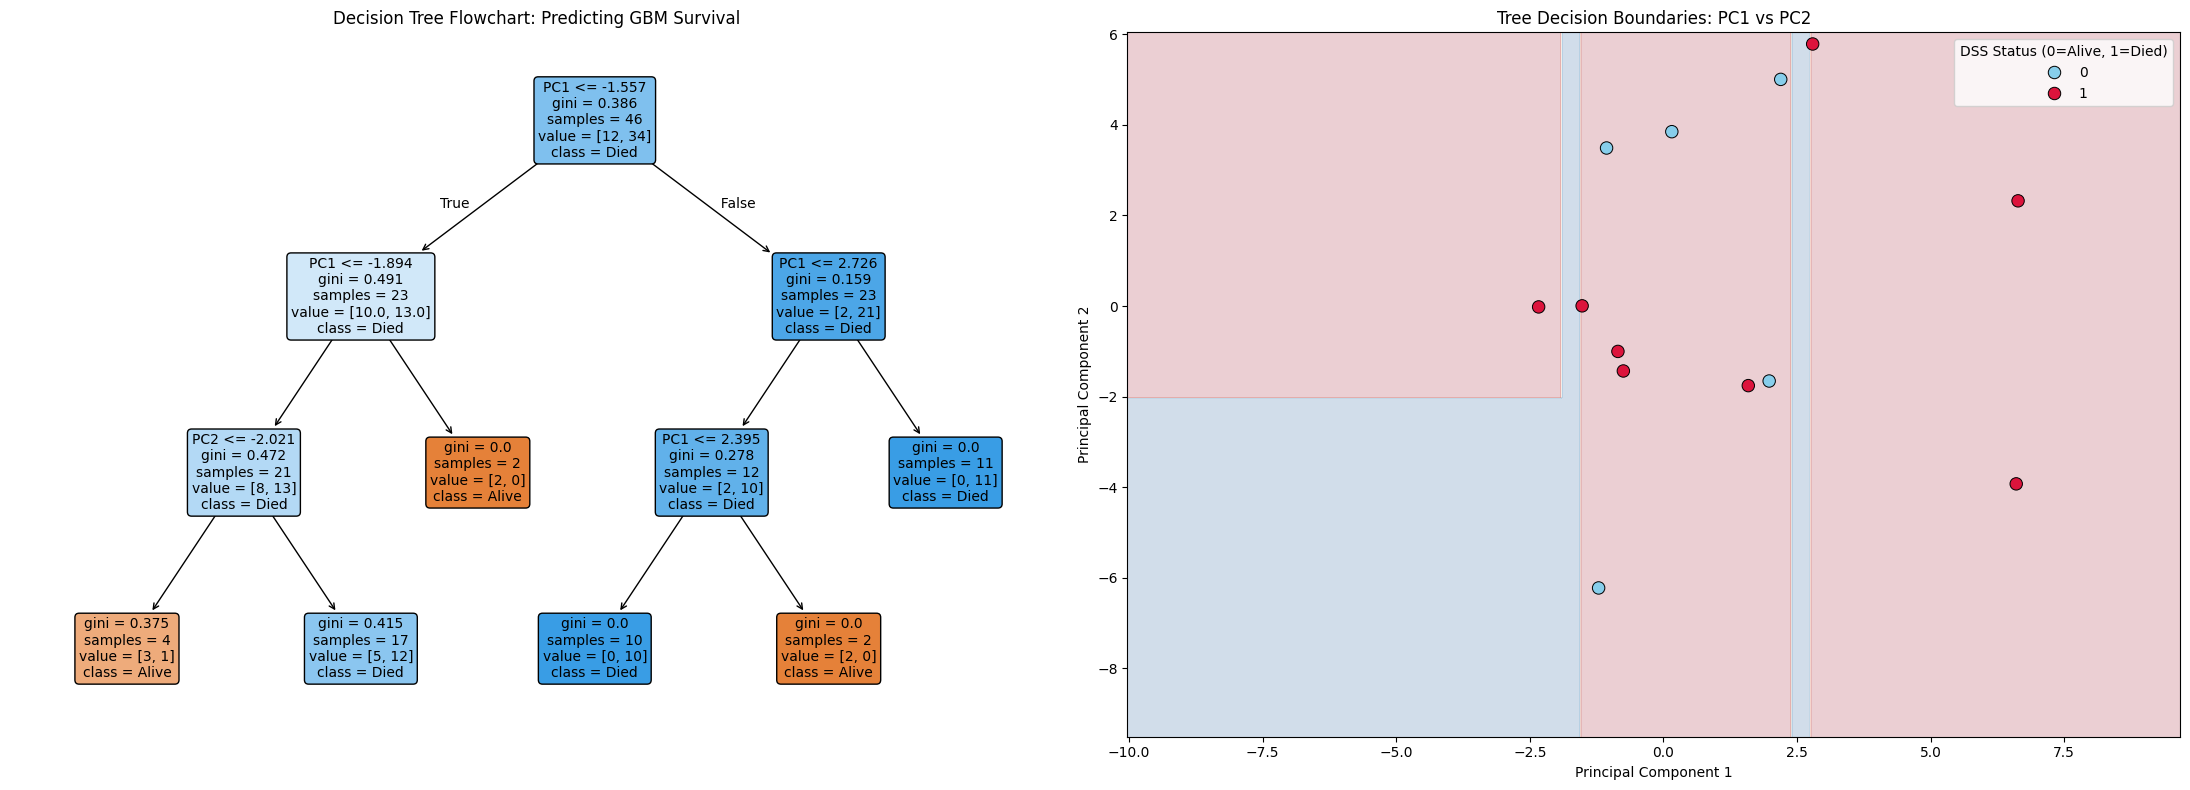

In [99]:
# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. LEFT SIDE: Tree Structure ---
plot_tree(tree_model, 
          feature_names=['PC1', 'PC2'], 
          class_names=['Alive', 'Died'], 
          filled=True, 
          rounded=True,
          fontsize=10,
          ax=ax[0]) # Pass the first axis
ax[0].set_title("Decision Tree Flowchart: Predicting GBM Survival")

# --- 2. RIGHT SIDE: Decision Boundaries ---
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get background predictions
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours on the second axis
ax[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r') 

# Add the scatterplot to the second axis
sns.scatterplot(
    x=X_val[:, 0], 
    y=X_val[:, 1], 
    hue=y_val.astype(str), 
    palette={'0': 'skyblue', '1': 'crimson'},
    edgecolor='black',
    s=80,
    ax=ax[1] # Pass the second axis
)

ax[1].set_title("Tree Decision Boundaries: PC1 vs PC2")
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].legend(title="DSS Status (0=Alive, 1=Died)")

plt.tight_layout()
plt.show()

Tree Accuracy: 0.87
Tree Accuracy: 0.62


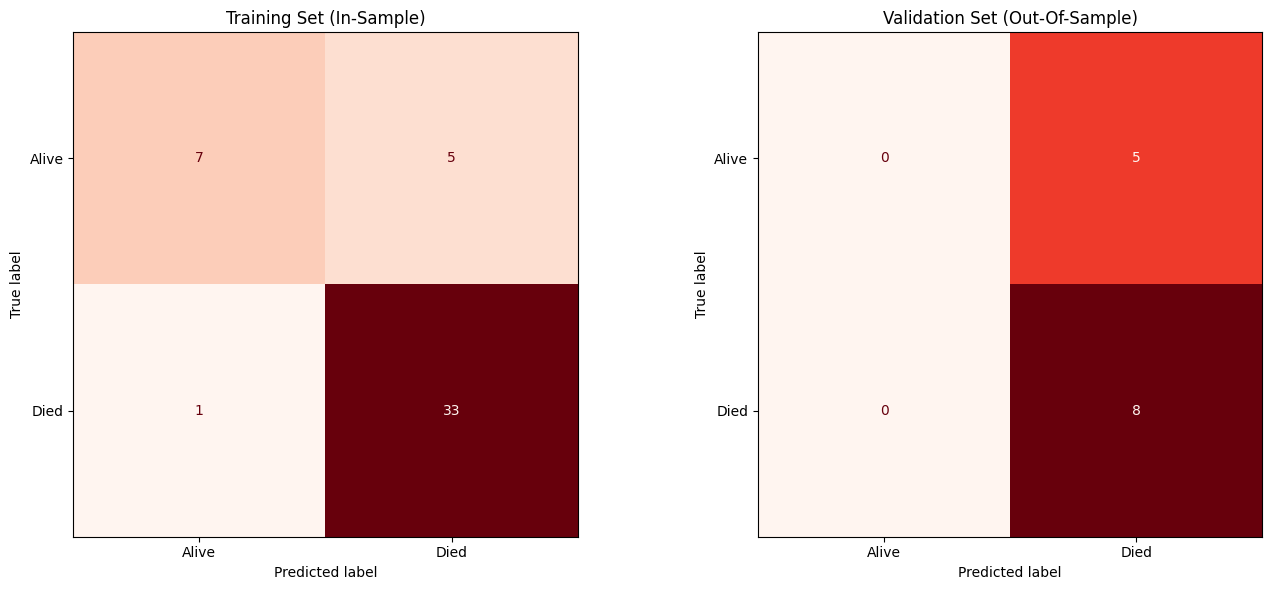

In [100]:
# Testing Accuracy for Both Training (70%) and Validation (20%) Data Set
print(f"Tree Accuracy: {tree_model.score(X_train, y_train):.2f}")
print(f"Tree Accuracy: {tree_model.score(X_val, y_val):.2f}")

# 1. Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- TRAINING SET (Left Side) ---
y_train_pred = tree_model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Alive', 'Died'])

# Plot to ax[0]
disp_train.plot(cmap='Reds', ax=ax[0], colorbar=False)
ax[0].set_title("Training Set (In-Sample)")

# --- VALIDATION SET (Right Side) ---
y_val_pred = tree_model.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Alive', 'Died'])

# Plot to ax[1]
disp_val.plot(cmap='Reds', ax=ax[1], colorbar=False)
ax[1].set_title("Validation Set (Out-Of-Sample)")

# Adjust layout and show
plt.tight_layout()
plt.show()

#### 4.2 Conclusion of Initial Decision Tree Model (Check-In 2)

Overall the models is performing well for in-sample accuracy of 87% but it's prediction decline in out-of-sample accuracy of 62%.

Examining the Confusion Matrix for out-of-sample data, the model produced 5 Type 1 Error (Predicted Died but is Alive) and 0 Type 2 Errors (Predicted Alive but died) in the validation dataset. This suggests the model is more prone to Type 1 error meaning it is more likely to over-predict mortality based on the selected angiogensis gene. Prefence for Type 1 Error is more beneficial for this model as it may be better to predict higher possible mortality rate to stress the importance of treatment in contrast to underestimating the mortality rate and not prioritize enough effort into treatment. (On the other hand, from an ethical perspective, if the patient is made aware of the data, it may cause them stress that their mortality rate could be high when in reality it is not.) For the training dataset, preference for Type 1 Error is likewise presented (7 Type 1 Error and 3 Type 2 Error.)

This model is likely underfitted right now simply due to the limitations of lack of available training datasets.

#### 4.3 Optimization of Decision Tree Model. 

The limitations of our group was the limitations on available datas, a vital component to training any machine learning algorthims. Other cancer type may have 80 samples for training and additional 80 for validation dataset, but for GBM, sample data for the validation dataset is missing. As such we have to split the 80 samples of the training data into 70% for Training and the remaining 30% for testing. This led to high likelyhood of undertraining. Our out-of-sample dataset perform really badly with an accuracy of only 60%. To solve this, we want to have more training data to ensure the model is better trained to predict. Still limited by the limited dataset, we decided to split the 80 samples into 80% training and 20% testing to have more training samples. In an ideal scenario, we are able to just have more training datas instead of having to take away from the testing data.

In [ ]:
# Using PCA data and labels of metadata after dropping NaNs asthe target
X_tree = X_pca 
y_tree = y_filtered.astype(int) 

# Stage 1: Split off the 70% Training set
# The remaining 20% goes into a temporary variable (X_temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tree, y_tree, test_size=0.20, random_state=42
)

# Stage 2: Split the 20% temporary set into Validation and Test. 10% each
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

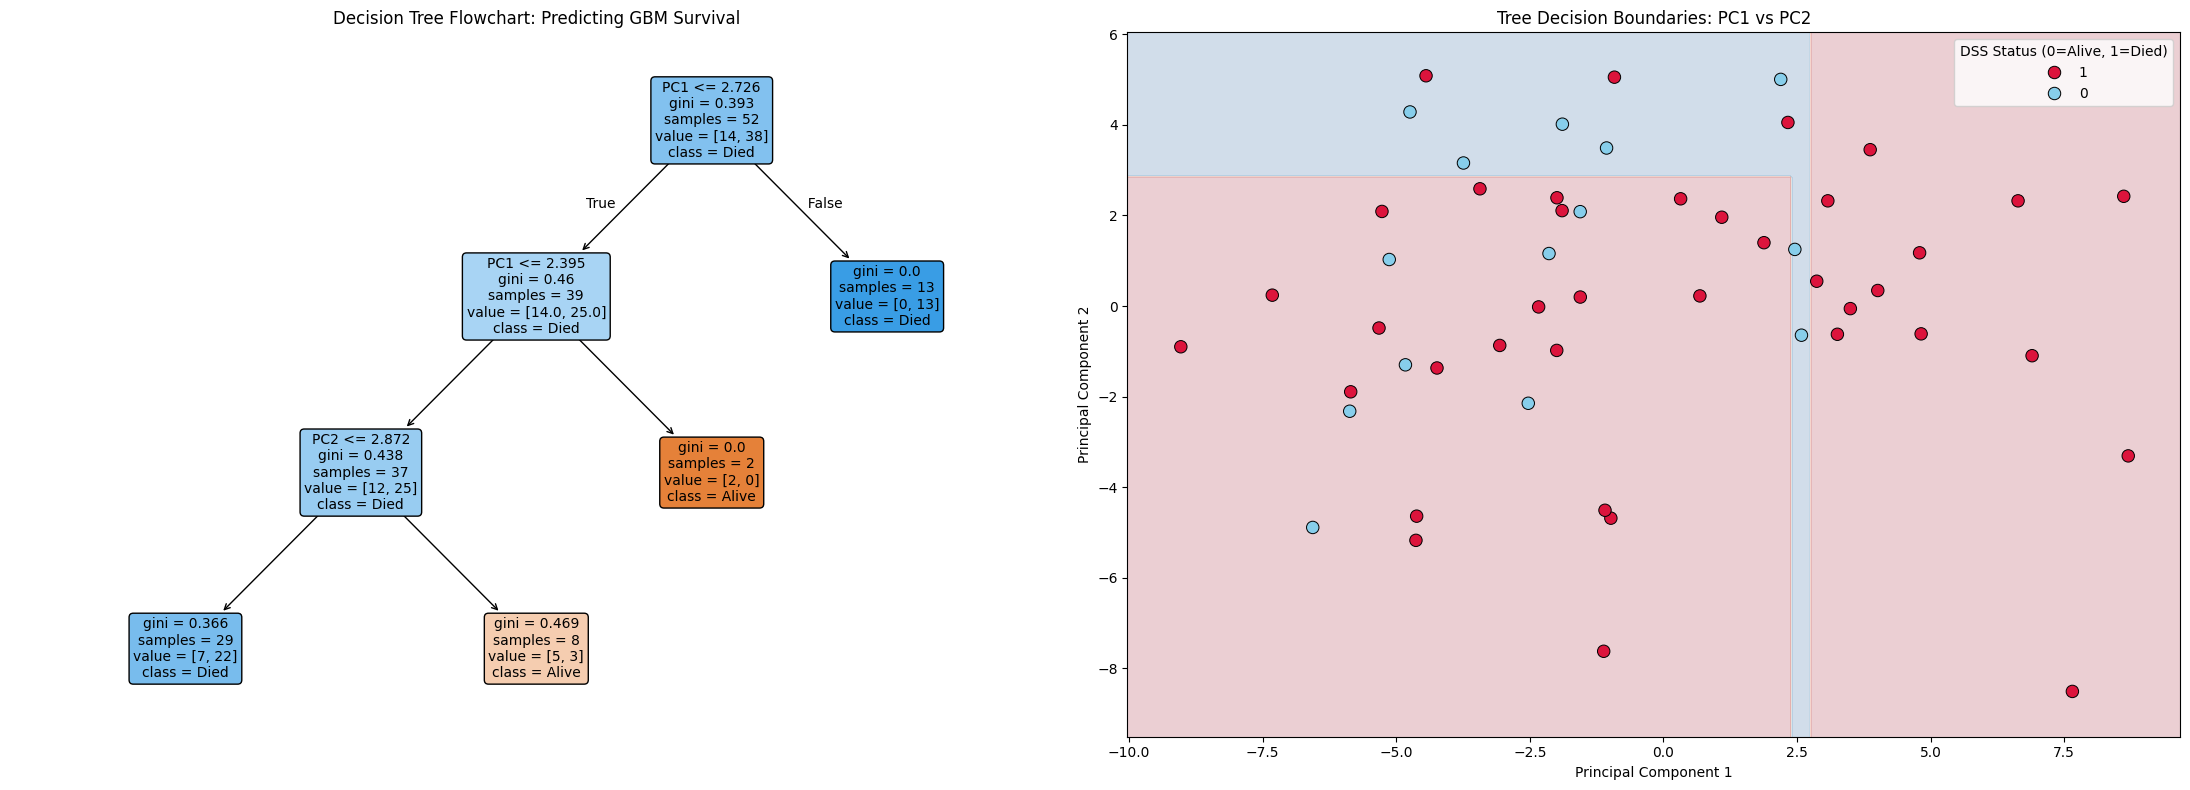

In [102]:
# Build the Decision Tree Model with max_depth of 3, meaning it can make 3 decisions splits
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)
# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. LEFT SIDE: Tree Structure ---
plot_tree(tree_model, 
          feature_names=['PC1', 'PC2'], 
          class_names=['Alive', 'Died'], 
          filled=True, 
          rounded=True,
          fontsize=10,
          ax=ax[0]) # Pass the first axis
ax[0].set_title("Decision Tree Flowchart: Predicting GBM Survival")

# --- 2. RIGHT SIDE: Decision Boundaries ---
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get background predictions
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours on the second axis
ax[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r') 

# Add the scatterplot to the second axis
sns.scatterplot(
    x=X_train[:, 0], 
    y=X_train[:, 1], 
    hue=y_train.astype(str), 
    palette={'0': 'skyblue', '1': 'crimson'},
    edgecolor='black',
    s=80,
    ax=ax[1] # Pass the second axis
)

ax[1].set_title("Tree Decision Boundaries: PC1 vs PC2")
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].legend(title="DSS Status (0=Alive, 1=Died)")

plt.tight_layout()
plt.show()

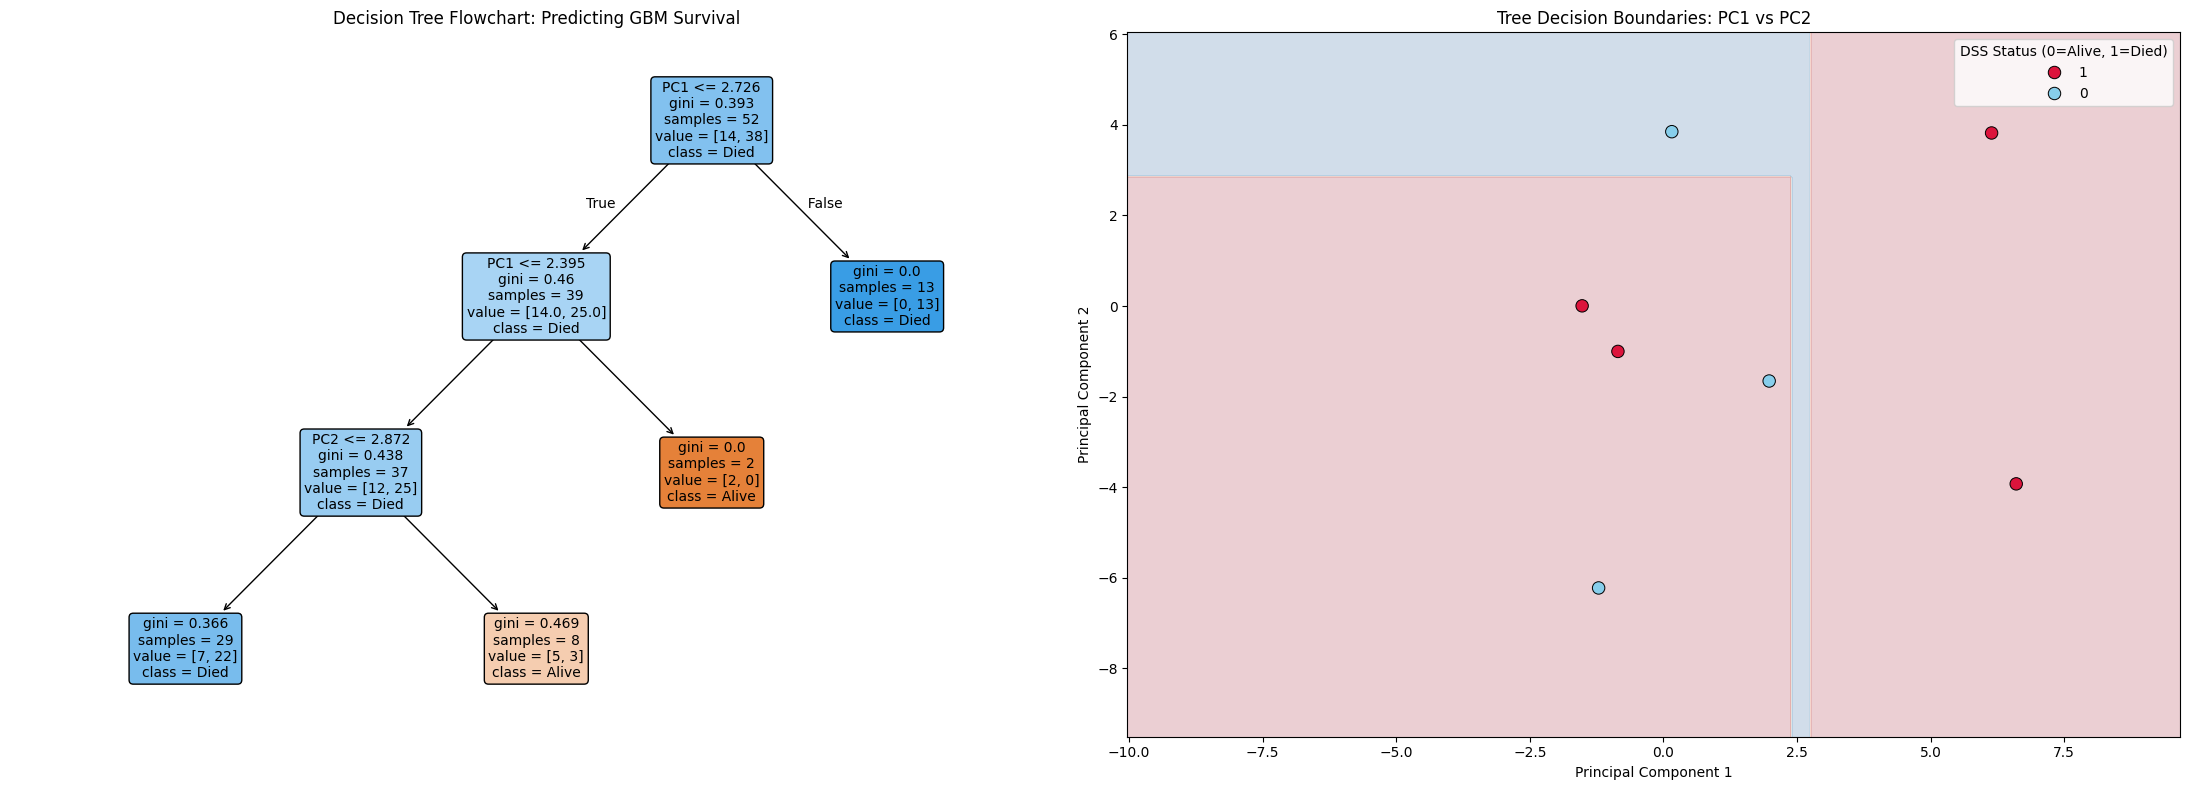

In [103]:
# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. LEFT SIDE: Tree Structure ---
plot_tree(tree_model, 
          feature_names=['PC1', 'PC2'], 
          class_names=['Alive', 'Died'], 
          filled=True, 
          rounded=True,
          fontsize=10,
          ax=ax[0]) # Pass the first axis
ax[0].set_title("Decision Tree Flowchart: Predicting GBM Survival")

# --- 2. RIGHT SIDE: Decision Boundaries ---
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get background predictions
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours on the second axis
ax[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r') 

# Add the scatterplot to the second axis
sns.scatterplot(
    x=X_val[:, 0], 
    y=X_val[:, 1], 
    hue=y_val.astype(str), 
    palette={'0': 'skyblue', '1': 'crimson'},
    edgecolor='black',
    s=80,
    ax=ax[1] # Pass the second axis
)

ax[1].set_title("Tree Decision Boundaries: PC1 vs PC2")
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].legend(title="DSS Status (0=Alive, 1=Died)")

plt.tight_layout()
plt.show()

Tree Accuracy: 0.81
Tree Accuracy: 0.71


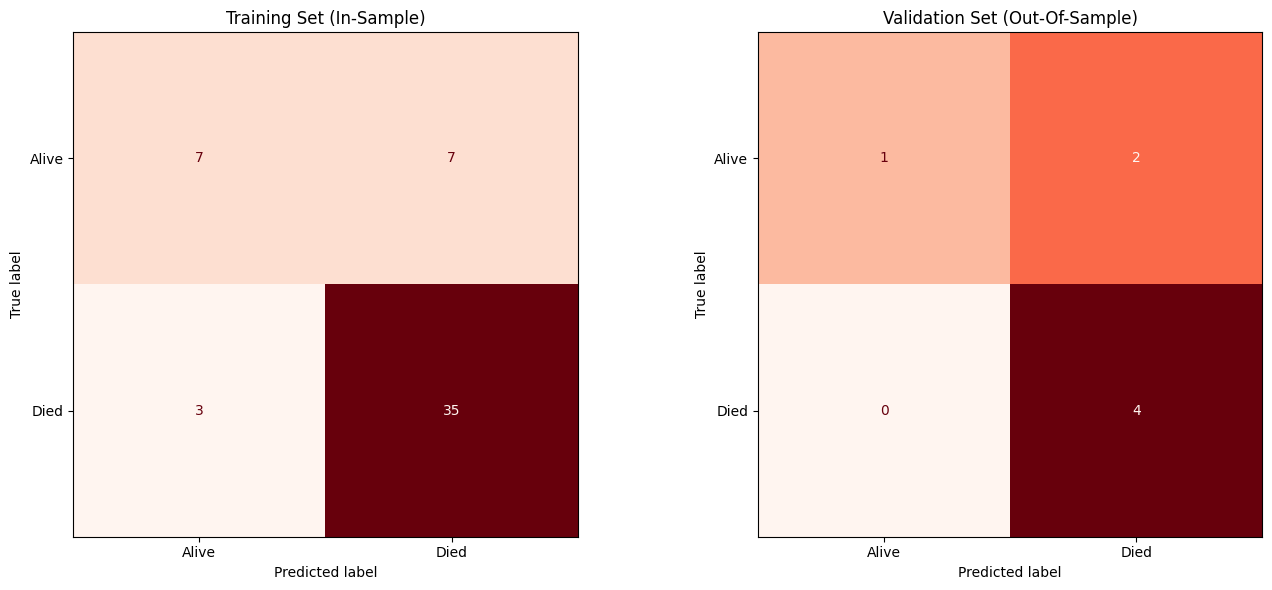

In [104]:
# Testing Accuracy for Both Training (80%) and Validation (20%) Data Set
print(f"Tree Accuracy: {tree_model.score(X_train, y_train):.2f}")
print(f"Tree Accuracy: {tree_model.score(X_val, y_val):.2f}")


# 1. Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- TRAINING SET (Left Side) ---
y_train_pred = tree_model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Alive', 'Died'])

# Plot to ax[0]
disp_train.plot(cmap='Reds', ax=ax[0], colorbar=False)
ax[0].set_title("Training Set (In-Sample)")

# --- VALIDATION SET (Right Side) ---
y_val_pred = tree_model.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Alive', 'Died'])

# Plot to ax[1]
disp_val.plot(cmap='Reds', ax=ax[1], colorbar=False)
ax[1].set_title("Validation Set (Out-Of-Sample)")

# Adjust layout and show
plt.tight_layout()
plt.show()

With increasing the size of the training data,this improved the out-of-sample accuracy from 62% to 71%.

#### 4.4 Verification and Validation of the Model

Here, we use the test dataset that we partioned earlier to perform out final verification outside of the original in-sample (training) and out-of-sample (validation) dataset. This dataset is new and have not been used in the previous training and validation of the model and represent a test of the model.

Tree Accuracy: 0.86


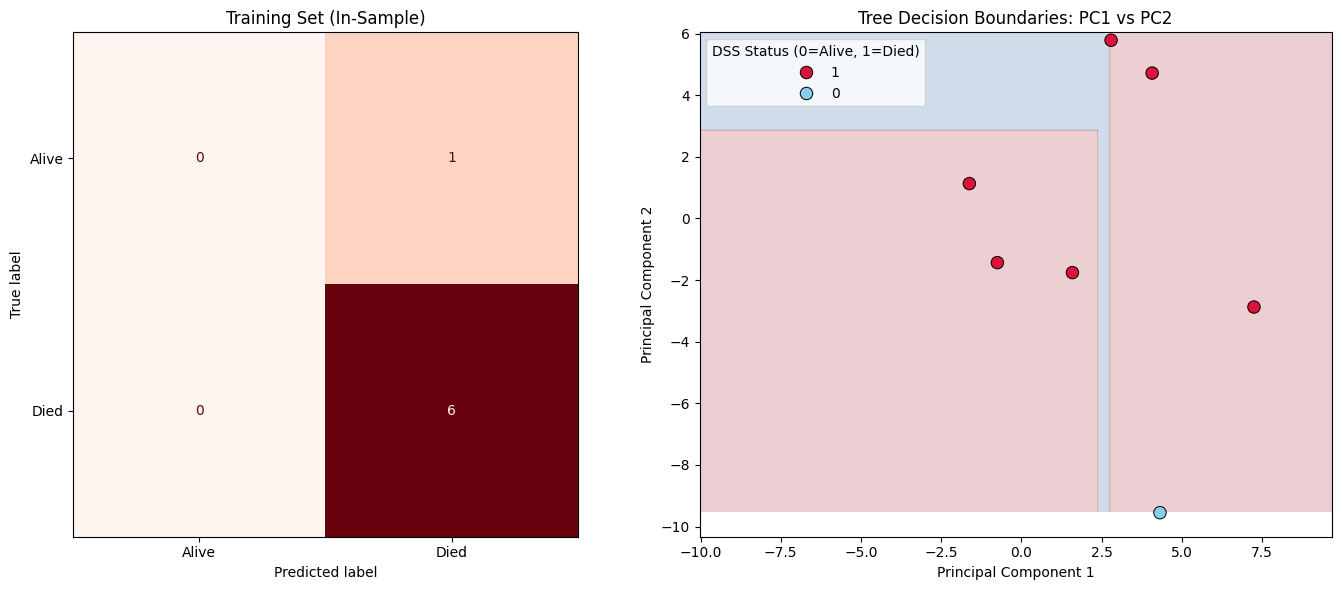

In [105]:
# Testing Accuracy for Both Testing (10%) Data Set
print(f"Tree Accuracy: {tree_model.score(X_test, y_test):.2f}")

# Get predictions for the validation set
y_test_pred = tree_model.predict(X_test)

# 1. Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Confusion Matrix SET (Left Side) ---
y_train_pred = tree_model.predict(X_test)
cm_train = confusion_matrix(y_test, y_test_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Alive', 'Died'])

# Plot to ax[0]
disp_train.plot(cmap='Reds', ax=ax[0], colorbar=False)
ax[0].set_title("Training Set (In-Sample)")


# --- 2. RIGHT SIDE: Decision Boundaries ---
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get background predictions
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours on the second axis
ax[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r') 

# Add the scatterplot to the second axis
sns.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    hue=y_test.astype(str), 
    palette={'0': 'skyblue', '1': 'crimson'},
    edgecolor='black',
    s=80,
    ax=ax[1] # Pass the second axis
)

ax[1].set_title("Tree Decision Boundaries: PC1 vs PC2")
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].legend(title="DSS Status (0=Alive, 1=Died)")

plt.tight_layout()
plt.show()

This 86% accuracy is actually higher than the out-of-sample accuracy. A large part of this is due to the limitation with the size of the dataset and it is possible that the dataset randomly partitioned to test set happened to fit in nicely with the Decision Tree Classification.

#### 4.5 Applications

The purpose of this Supervised Machine Learning Model is given patient angiogenesis RNA gene expression, be able to predict the disease specific mortality rate (DSS 1 : Died, 0 : Alive). Here, we perform some sample applications of this tool by applying new patient data into this model and having it predicts mortality rate. The patients with the prediction of 1 (disease) should be prioritized in aggressive cancer treatment and interventions as they hold the highest risks.

This section uses same logic as part 1 where we filter out the data for the data of interest (GBM patients with only the angiogenesis hallmark gene expression.) Then it is applied to the same PCA axis and decision tree is utilized to predict DSS.

In [106]:
data = pd.read_csv(
    '../Data/TEST_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  
metadata_df = pd.read_csv(
    '../Data/TEST_SET_GSE62944_metadata.csv', index_col=0, header=0)
#print(data.head())

cancer_type = 'GBM'  # Glioblastoma Multiforme

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
#print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
GBM_data = data[cancer_samples]

desired_gene_list = [
    'VEGFA', 'VEGFB', 'KDR', 'CXCR1', 'CXCR2', 'HIF1A', 'PDGFB', 'MYC', 'CDH5', 'KRAS', 'IL8',
    'CXCR4', 'CXCL13', 'FLT4', 'RHOA', 'TGFB2', 'GAB1', 'STAT3', 'LCK', 'FZD4', 'PDPK1', 'MTOR',
    'CXCL12', 'ITGA5', 'PLCG1', 'RRAS', 'ENG', 'TNFSF12', 'PTPN11', 'TGFBR1', 'TERT', 'PIK3CD',
    'PTK2B', 'FGF2', 'NOS3', 'VTN', 'CCL24', 'SMO', 'PRKCG', 'RAF1', 'BRCA1', 'CCL2',
    'TGFBR2', 'EGFR', 'VAV2', 'IL6', 'ERBB2', 'PRKCA', 'ROCK1', 'TNF', 'IL1B', 'SDC4', 'PRKACA',
    'CX3CR1', 'ITGB1', 'PDGFA', 'CD40', 'MAPK1', 'PIK3R1', 'CSF3', 'HGF', 
    'IL10', 'MET', 'TP53', 'SDC2', 'TGFB1', 'AKT1', 'FLT1', 'CAV1', 'ARNT', 'ARHGEF1', 'PDGFRA',
    'HSPB1', 'TWIST1', 'ITGB3', 'AKT3', 'MMP1', 'MAPK3', 'SPHK1', 'EPAS1', 'TIMP3', 'SRC',
    'CXCL10', 'MAP2K1', 'WNT5A', 'EFNA1', 'IGF1', 'ROCK2', 'GATA2', 'VEGFC', 
    'CTNNB1', 'TEK', 'FN1', 'EPHA2', 'IGF1R', 'THBS1', 'FES', 'ITGAV', 'CXCL9', 'CCL11',
    'CXCR3', 'PRKCB', 'ACVRL1', 'HRAS', 'ESR1', 'TGFB3', 'PLAUR', 'RAC1', 'NF1', 'ANGPT2',
    'GRB2', 'PIK3CA', 'IL1A'
]

gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
GBM_gene_data = GBM_data.loc[gene_list]
#print(GBM_gene_data)

In [107]:
# 1. Transpose the test data so Patients are Rows
X_test_raw = GBM_gene_data.T

# 2. Alignment: Ensure the test set has the exact same genes as the training set
# This is mandatory for the PCA transform to work correctly
X_test_aligned = X_test_raw.reindex(columns=X_filtered.columns, fill_value=0)

# 3. Project onto the Training PCA Axis
# We use the 'pca' object from your training session
X_test_pca = pca.transform(X_test_aligned)

# 4. Correctly extract labels for the TEST set samples only
# Use X_test_aligned.index to ensure we only pull metadata for the test samples
#y_test = metadata_df.loc[X_test_aligned.index, 'DSS'].astype(int)

# 5. Evaluate the model on the Test Data
#print(f"Test Set Accuracy: {tree_model.score(X_test_pca, y_test):.2f}")

# 6. Confusion Matrix for the Test Set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred = tree_model.predict(X_test_pca)

print(f"{'Patient Sample ID':<40} | {'Predicted Outcome'}")
print("-" * 60)
for patient_id, prediction in zip(X_test_aligned.index, y_test_pred):
    # Convert numerical prediction to a readable string
    status = "Died (1.0)" if prediction == 1 else "Alive (0.0)"
    print(f"{patient_id:<40} | {status}")

Patient Sample ID                        | Predicted Outcome
------------------------------------------------------------
TCGA-06-0747-01A-01R-1849-01             | Died (1.0)
TCGA-19-2625-01A-01R-1850-01             | Died (1.0)
TCGA-14-0790-01B-01R-1849-01             | Died (1.0)
TCGA-76-4925-01A-01R-1850-01             | Died (1.0)
TCGA-06-0152-02A-01R-2005-01             | Alive (0.0)
TCGA-27-1832-01A-01R-1850-01             | Died (1.0)
TCGA-28-2509-01A-01R-1850-01             | Died (1.0)
TCGA-28-2499-01A-01R-1850-01             | Died (1.0)
TCGA-41-5651-01A-01R-1850-01             | Died (1.0)
TCGA-06-0745-01A-01R-1849-01             | Died (1.0)
TCGA-26-5132-01A-01R-1850-01             | Died (1.0)
TCGA-06-0132-01A-02R-1849-01             | Died (1.0)
TCGA-32-2638-01A-01R-1850-01             | Alive (0.0)
TCGA-12-0618-01A-01R-1849-01             | Died (1.0)
TCGA-06-0878-01A-01R-1849-01             | Died (1.0)
TCGA-06-0686-01A-01R-1849-01             | Died (1.0)
TCGA-32-2634

## Conclusions and Ethical Implications: 

The goal of this project is to investigate the question of whether or not expression of angiogenesis hallmark can predict Disease-Specific Survival (DSS) (Mortality Rate) of Glioblastoma Patients. We were first able to visualized that there is perhaps a relationship presented between angiogenesis hallmark and mortality rate using K-Mean Clustering, we observed different precentage of mortality associated with each cluster. (Mortality rate is still high above 50% for all three clusters showing that Angiogenesis factor is not a sole determinated of mortality.) Since there is a different precentage with different cluster, it confirms that some relationship is presented between angiogenesis gene expression and Gliblastoma mortality rate. We then utilize the supervised learning method of decision tree to create a decision tree model to predict disease specific survival of Glioblastoma patient based solely on the Angiogenesis Gene Expression (After adjusted to highest variance with PCA for analysis). With this model, we were able to get a final accuracy of 81%, 71%, 86% Accuracy for Training, Validating, and Testing dataset respectfully. The specific numbers of the accuracy may be a bit misleading as this could simply be due to the limitation of the dataset and the data presented just happened to fit nicely with the model, nevertheless, the accuracy is still shown better than 50% (at random). and getting close to 70-80% accuracy showing that angiogenesis factor can be use to predict DSS.

There is various important ethical implication of this study. A possible utilize of this model is to predict mortality rate of Glioblastoma Patient to classify the severity of the disease. The more severe the disease, it may prompt more serious and agressive treatment to try to reduce those factors. This can be a helpful tool in healthcare to help provide an estimate of severity and the degree of involvement needing to address the cancer. However, this tool can also contribute in the opposite direction of rather than focusing more resources and treatment for the patient that may be more severe, it may demed those patient as harder to save and instead led to identification of lower severity/risk patients and prioritize treating those instead (Resource Prioritzation). Furthermore, the output of the model can also contribute ethical implications to the patients. With this model it has a preference for Type 1 Error (predict died but is alive), this is important to not underestimate mortality rate and not prioritize enough effort into treatment. However, for patients that may be misidentified as carrying high mortality risk, this may be unnecessary additional stress and anxiety on top of the original pre-existing mental conditions of being diagnosied with an agressive brain cancer. In addition, the model is also trained on specific publically available TCGA datasets, this may led to more generalized predictions rather than address specific populations such as difference in sex, ethnicities, or ages (Algorithm Bias). Lastly, as with all model, an important ethical implication of the model is the accuracy, ensuring it is accurate prior to being use in any research or healthcare settings.

## Limitations and Future Work: 

Major limitations of our machine learning model is the limitation of datasets, we only have 80 available dataset to do both training, validating, and testing. This is not enough to create an accurate and testable model. As seen in section 4.2 Optimization of Decision Tree Model, by adding more datasets, it is helping improving the out-of-sample prediction accuracy. Even though the final accuracy metrics of the testing dataset is high at 86%, due to the limited number of data to an extremely small number (7 samples), it is really not able to give a good perspective on the accuracy of the model. A major future work for the improvement of this model is by feeding it more datasets to train and test on to improve the accuracy and reliablity of the result.

Other limitations is the scope of knowledge and time. The machiene learning algorithms implemented are easier to understand and use, and with the limtiations on time, there is limited dive into more complex algorithm. Future work can aim at using more complex algorithm to examine the relationship between angiogenesis hallmark and glioblastoma, such as using Random Forest Method and even being able to see influence of specific gene and not just overall PCA component.

Another area of interesting future work is examining the relationship between Glioblastoma and Brain Arteriovenous Malformation (bAVM). Recently, there is some studies that reports the co-existence of Brain Arteriovenous Malformation alongside Glioblastoma Multiforme (GBM). (Tunthanathip & Kanjanapraditm, 2020) While the incidence is rare, with only approximately 60 reported cases recorded by 2020, it illustrate the interesting presentation of multiple diseases that can co-exist and co-present with each other. In Brain Arteriovenous Malformation, it is recently discovered that 95% of bAVM is associated with sporadic gene mutations with the two two most common mutations relating to KRAS and BRAF. KRAS and BRAF mutations have also been reported in Glioblastoma Tumors.(Di Nunno et al., 2023) KRAS and BRAF genes are also involved in the angiognesis pathway (particularly through the MAPK Pathway) and it offers an interesting overview on relationship between different diseases. Future work can first identify the precense of KRAS and BRAF mutations on the co-occurence of GBM and bAVM and then examine the angiogenesis hallmark to see if there is a difference between co-occurence of GBM and bAVM in contrast to GBM without bAVM.

## Bibliography : 

Biterge-Sut B. (2020). A comprehensive analysis of the angiogenesis-related genes in glioblastoma multiforme vs. brain lower grade glioma. Arquivos de neuro-psiquiatria, 78(1), 34–38. https://doi.org/10.1590/0004-282X20190131

D'Alessio, A., Proietti, G., Lama, G., Biamonte, F., Lauriola, L., Moscato, U., Vescovi, A., Mangiola, A., Angelucci, C., & Sica, G. (2016). Analysis of angiogenesis related factors in glioblastoma, peritumoral tissue and their derived cancer stem cells. Oncotarget, 7(48), 78541–78556. https://doi.org/10.18632/oncotarget.12398

Di Nunno, V., Gatto, L., Tosoni, A., Bartolini, S., & Franceschi, E. (2023). Implications of BRAF V600E mutation in gliomas: Molecular considerations, prognostic value and treatment evolution. Frontiers in oncology, 12, 1067252. https://doi.org/10.3389/fonc.2022.1067252

Ohgaki, H., & Kleihues, P. (2013). The definition of primary and secondary glioblastoma. Clinical cancer research : an official journal of the American Association for Cancer Research, 19(4), 764–772. https://doi.org/10.1158/1078-0432.CCR-12-3002

Tunthanathip, T., & Kanjanapradit, K. (2020). Glioblastoma Multiforme Associated with Arteriovenous Malformation: A Case Report and Literature Review. Annals of Indian Academy of Neurology, 23(1), 103–106. https://doi.org/10.4103/aian.AIAN_219_18

